In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("data.csv")

# View first 5 rows
print(df.head())

   Order_ID        Date Region     Product     Category  Sales  Quantity  \
0      1001  2024-01-05  North      Laptop  Electronics  55000         2   
1      1002  2024-01-07  South      Mobile  Electronics  20000         3   
2      1003  2024-01-10   East       Chair    Furniture   5000         5   
3      1004  2024-01-12   West       Table    Furniture   7000         2   
4      1005  2024-01-15  North  Headphones  Electronics   2000         4   

   Profit  
0    5000  
1    3000  
2     800  
3    1200  
4     400  


In [9]:
print(df.info())        # Data types & null values
print(df.describe())   # Statistical summary
print(df.shape)        # Rows & columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  20 non-null     int64 
 1   Date      20 non-null     object
 2   Region    20 non-null     object
 3   Product   20 non-null     object
 4   Category  20 non-null     object
 5   Sales     20 non-null     int64 
 6   Quantity  20 non-null     int64 
 7   Profit    20 non-null     int64 
dtypes: int64(4), object(4)
memory usage: 1.4+ KB
None
         Order_ID         Sales   Quantity       Profit
count    20.00000     20.000000  20.000000    20.000000
mean   1010.50000  20750.000000   2.800000  2622.500000
std       5.91608  20755.252981   1.321881  1951.414804
min    1001.00000   2000.000000   1.000000   400.000000
25%    1005.75000   5150.000000   2.000000   875.000000
50%    1010.50000  15500.000000   2.500000  2600.000000
75%    1015.25000  22500.000000   4.000000  3575.000000
max    1020.000

In [10]:
print(df.isnull().sum())

Order_ID    0
Date        0
Region      0
Product     0
Category    0
Sales       0
Quantity    0
Profit      0
dtype: int64


In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

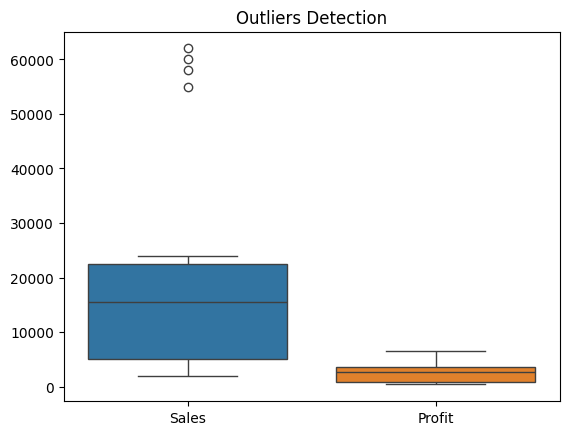

In [14]:
sns.boxplot(data=df[['Sales', 'Profit']])
plt.title("Outliers Detection")
plt.show()

In [15]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Sales'] >= Q1 - 1.5*IQR) & (df['Sales'] <= Q3 + 1.5*IQR)]

In [16]:
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)

Region
East     12700
North     8800
South    80000
West     78500
Name: Sales, dtype: int64


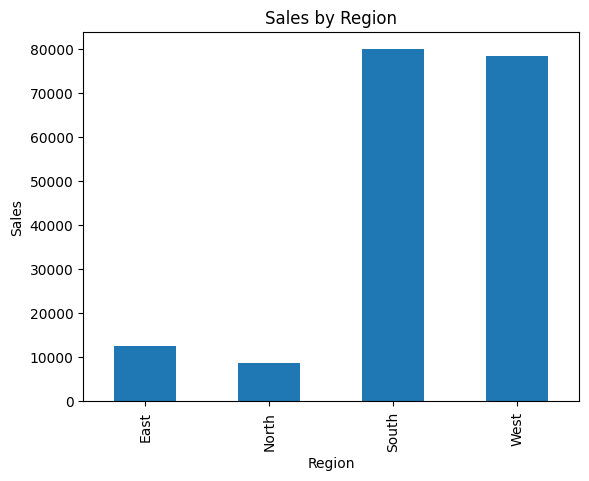

In [17]:
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

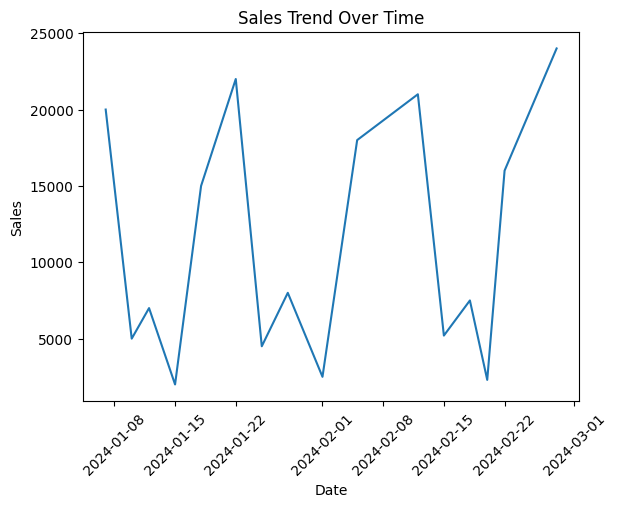

In [18]:
df.sort_values('Date', inplace=True)

plt.plot(df['Date'], df['Sales'])
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

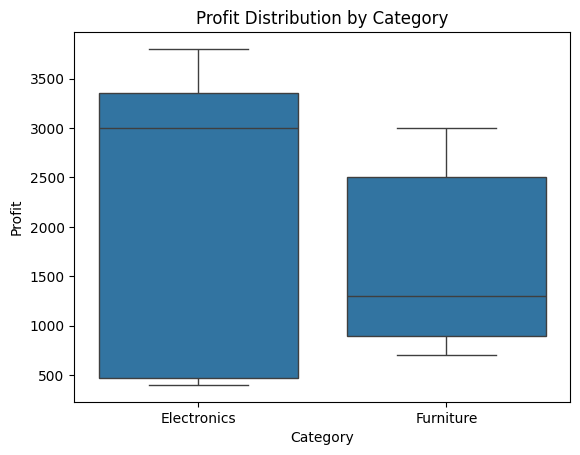

In [19]:
sns.boxplot(x='Category', y='Profit', data=df)
plt.title("Profit Distribution by Category")
plt.show()

In [20]:
df.to_csv("cleaned_data.csv", index=False)